In [ ]:
# !pip install umap-learn

   ---------------------------------------- 0.0/91.8 kB ? eta -:--:--
   ----------------------------------- ---- 81.9/91.8 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 91.8/91.8 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.5 kB ? eta -:--:--
   ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import umap
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ── Styling ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#4361ee','#f72585','#4cc9f0','#7209b7','#fb8500','#2dc653','#e63946','#adb5bd']

In [ ]:
# 1. LOAD & CLEAN DATA

df = pd.read_csv('../data/processed/tmdb_movies_clean_csv/tmdb_movies_clean.csv')

# Convert numeric columns
for col in ['Duration', 'TMDB Rating', 'Votes']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean Certificate — hanya nilai valid
valid_certs = ['NR', 'PG-13', 'R', 'PG', 'G', 'NC-17']
df['Certificate'] = df['Certificate'].where(df['Certificate'].isin(valid_certs), 'Unknown')

# Drop rows dengan nilai penting yang null
df = df.dropna(subset=['TMDB Rating', 'Votes', 'Duration', 'Popularity', 'Genre', 'Original Language'])
df = df.reset_index(drop=True)

# Hapus baris dengan Genre yang bukan string genre valid (misal angka ID)
df = df[df['Genre'].str.match(r'^[A-Za-z, /]+$', na=False)].reset_index(drop=True)

print(f"  → Dataset bersih: {len(df):,} film")

  → Dataset bersih: 18,449 film


In [ ]:
# 2. FEATURE ENGINEERING
# Genre one-hot encoding 
MAIN_GENRES = ['Action','Adventure','Animation','Comedy','Crime',
               'Documentary','Drama','Family','Fantasy','History',
               'Horror','Music','Mystery','Romance','Science Fiction',
               'Thriller','War','Western']

for genre in MAIN_GENRES:
    col = f'genre_{genre.replace(" ","_")}'
    df[col] = df['Genre'].apply(lambda x: 1 if genre in str(x) else 0)

# Original Language — top 8 + other 
top_langs = df['Original Language'].value_counts().head(8).index.tolist()
for lang in top_langs:
    df[f'lang_{lang}'] = (df['Original Language'] == lang).astype(int)

# Certificate encoding 
cert_map = {'G': 1, 'PG': 2, 'PG-13': 3, 'R': 4, 'NC-17': 5, 'NR': 3, 'Unknown': 3}
df['cert_encoded'] = df['Certificate'].map(cert_map)

# Log-transform skewed numerics 
df['log_votes']      = np.log1p(df['Votes'])
df['log_popularity'] = np.log1p(df['Popularity'])
df['log_grossed']    = np.log1p(df['Grossed in $'].fillna(0))

# Feature matrix 
genre_cols = [f'genre_{g.replace(" ","_")}' for g in MAIN_GENRES]
lang_cols  = [f'lang_{l}' for l in top_langs]
num_cols   = ['TMDB Rating', 'log_votes', 'Duration',
              'log_popularity', 'log_grossed', 'cert_encoded']

feature_cols = num_cols + genre_cols + lang_cols
X_raw = df[feature_cols].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"  → {X_scaled.shape[1]} fitur siap digunakan")

  → 32 fitur siap digunakan


In [15]:
# 3. DIMENSIONALITY REDUCTION (PCA + UMAP)
pca_full = PCA(n_components=15, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)
print(f"  → PCA 15 komponen menjelaskan {explained[-1]*100:.1f}% variansi")

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=42, verbose=False)
X_umap = reducer.fit_transform(X_scaled)
print("  → UMAP selesai")

  → PCA 15 komponen menjelaskan 69.1% variansi
  → UMAP selesai


In [16]:
# 4. ELBOW + SILHOUETTE UNTUK CARI K OPTIMAL
k_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_full)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_full, labels, sample_size=3000))
    db_scores.append(davies_bouldin_score(X_pca_full, labels))
    print(f"  k={k}: sil={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}")

best_k = list(k_range)[np.argmax(sil_scores)]
print(f"\n k optimal = {best_k} (silhouette tertinggi: {max(sil_scores):.4f})")

  k=2: sil=0.1234  DB=2.1350
  k=3: sil=0.1573  DB=2.0077
  k=4: sil=0.1480  DB=2.2204
  k=5: sil=0.1607  DB=2.0224
  k=6: sil=0.1745  DB=1.8267
  k=7: sil=0.1806  DB=1.6801
  k=8: sil=0.1931  DB=1.5074
  k=9: sil=0.2045  DB=1.4843
  k=10: sil=0.2273  DB=1.4092

 k optimal = 10 (silhouette tertinggi: 0.2273)


In [ ]:
# 5. FIT SEMUA ALGORITMA

# K-Means 
km_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
km_labels = km_model.fit_predict(X_pca_full)

# DBSCAN 
# eps di-tuning pakai k-distance dari knn; pakai ~0.8 sebagai heuristik
dbscan = DBSCAN(eps=2.5, min_samples=15, n_jobs=-1)
db_labels_raw = dbscan.fit_predict(X_pca_full)
n_db_clusters = len(set(db_labels_raw)) - (1 if -1 in db_labels_raw else 0)
n_noise = (db_labels_raw == -1).sum()

# Hierarchical
hc_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels = hc_model.fit_predict(X_pca_full)

# Evaluasi
# DBSCAN: evaluasi hanya pada non-noise points
db_mask = db_labels_raw != -1
db_labels_eval = db_labels_raw[db_mask]
X_db_eval = X_pca_full[db_mask]

results = {}
results['K-Means'] = {
    'labels': km_labels,
    'n_clusters': best_k,
    'silhouette': silhouette_score(X_pca_full, km_labels, sample_size=3000),
    'db_score':   davies_bouldin_score(X_pca_full, km_labels),
}
if n_db_clusters >= 2 and len(set(db_labels_eval)) >= 2:
    results['DBSCAN'] = {
        'labels': db_labels_raw,
        'n_clusters': n_db_clusters,
        'noise_pct': n_noise / len(db_labels_raw) * 100,
        'silhouette': silhouette_score(X_db_eval, db_labels_eval, sample_size=3000),
        'db_score':   davies_bouldin_score(X_db_eval, db_labels_eval),
    }
else:
    results['DBSCAN'] = {
        'labels': db_labels_raw,
        'n_clusters': n_db_clusters,
        'noise_pct': n_noise / len(db_labels_raw) * 100,
        'silhouette': None,
        'db_score': None,
    }
results['Hierarchical'] = {
    'labels': hc_labels,
    'n_clusters': best_k,
    'silhouette': silhouette_score(X_pca_full, hc_labels, sample_size=3000),
    'db_score':   davies_bouldin_score(X_pca_full, hc_labels),
}

print("\n  ┌─────────────────────┬────────────┬──────────────┬──────────────┐")
print("  │ Algoritma           │ N Cluster  │ Silhouette ↑ │ Davies-Boul ↓│")
print("  ├─────────────────────┼────────────┼──────────────┼──────────────┤")
for name, r in results.items():
    sil = f"{r['silhouette']:.4f}" if r['silhouette'] else "  N/A  "
    db  = f"{r['db_score']:.4f}"   if r['db_score']   else "  N/A  "
    print(f"  │ {name:<20}│ {r['n_clusters']:<10} │ {sil:<12} │ {db:<12} │")
print("  └─────────────────────┴────────────┴──────────────┴──────────────┘")

# Tentukan pemenang
valid = {k: v for k, v in results.items() if v['silhouette'] is not None}
best_algo = max(valid, key=lambda k: valid[k]['silhouette'])
print(f"\nAlgoritma terbaik: {best_algo} (silhouette={valid[best_algo]['silhouette']:.4f})")



  ┌─────────────────────┬────────────┬──────────────┬──────────────┐
  │ Algoritma           │ N Cluster  │ Silhouette ↑ │ Davies-Boul ↓│
  ├─────────────────────┼────────────┼──────────────┼──────────────┤
  │ K-Means             │ 10         │ 0.2342       │ 1.3950       │
  │ DBSCAN              │ 19         │ 0.1713       │ 1.0869       │
  │ Hierarchical        │ 10         │ 0.1959       │ 1.5352       │
  └─────────────────────┴────────────┴──────────────┴──────────────┘

Algoritma terbaik: K-Means (silhouette=0.2342)


In [20]:
%matplotlib inline

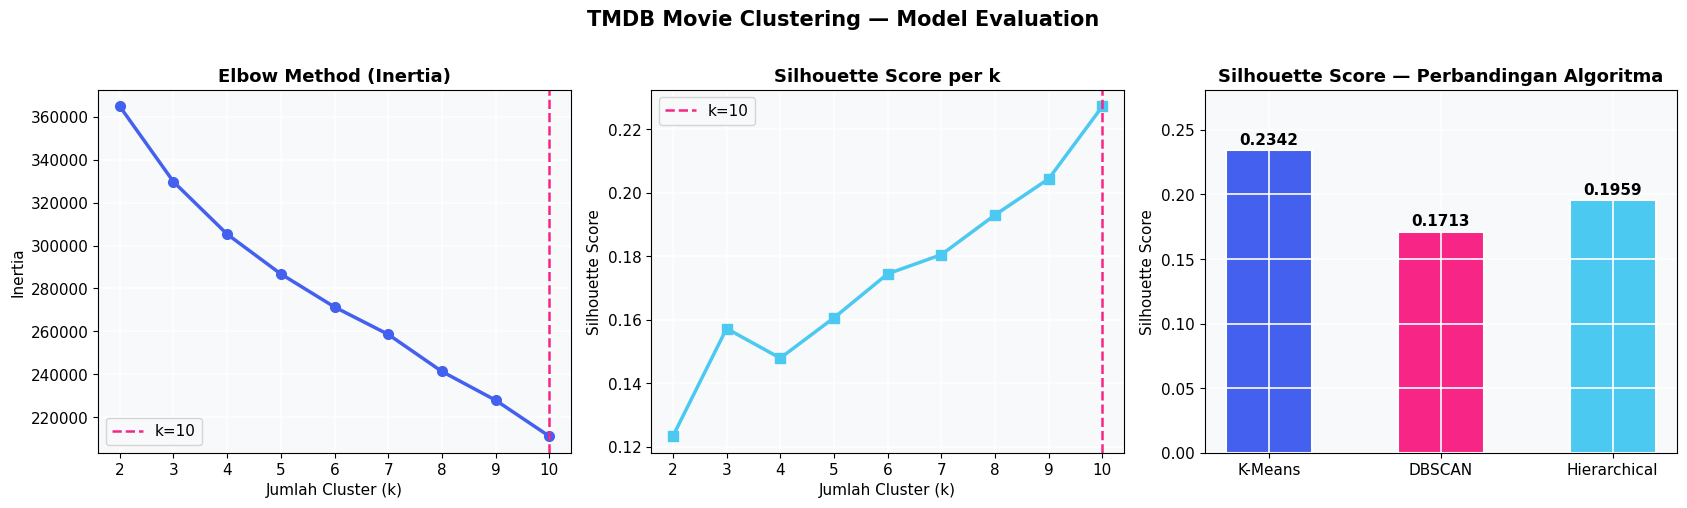

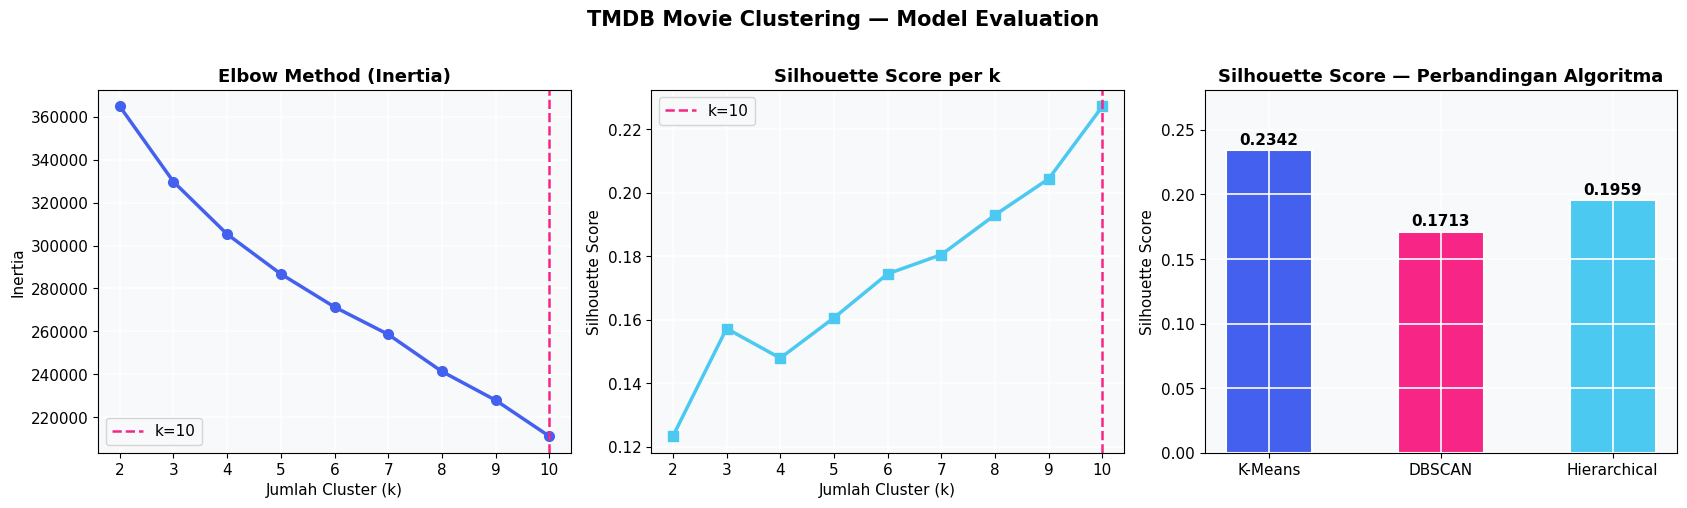

In [ ]:
# 6. VISUALISASI
best_labels = results[best_algo]['labels']
# Untuk DBSCAN ganti -1 dengan label 'Noise'
df['cluster'] = best_labels
df['cluster_str'] = df['cluster'].apply(
    lambda x: f'Cluster {x+1}' if x >= 0 else 'Noise'
)

# Figure 1: Elbow + Silhouette + Algoritma comparison
fig1, axes = plt.subplots(1, 3, figsize=(17, 5))
fig1.suptitle('TMDB Movie Clustering — Model Evaluation', fontsize=15, fontweight='bold', y=1.01)

# Elbow
axes[0].plot(list(k_range), inertias, 'o-', color='#4361ee', linewidth=2.5, markersize=7)
axes[0].axvline(best_k, color='#f72585', linestyle='--', linewidth=1.8, label=f'k={best_k}')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette per k
axes[1].plot(list(k_range), sil_scores, 's-', color='#4cc9f0', linewidth=2.5, markersize=7)
axes[1].axvline(best_k, color='#f72585', linestyle='--', linewidth=1.8, label=f'k={best_k}')
axes[1].set_title('Silhouette Score per k')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

# Bar comparison algoritma
algo_names = list(valid.keys())
sil_vals   = [valid[a]['silhouette'] for a in algo_names]
colors_bar = PALETTE[:len(algo_names)]
bars = axes[2].bar(algo_names, sil_vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sil_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].set_title('Silhouette Score — Perbandingan Algoritma')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_ylim(0, max(sil_vals) * 1.2)

plt.tight_layout()
plt.show()

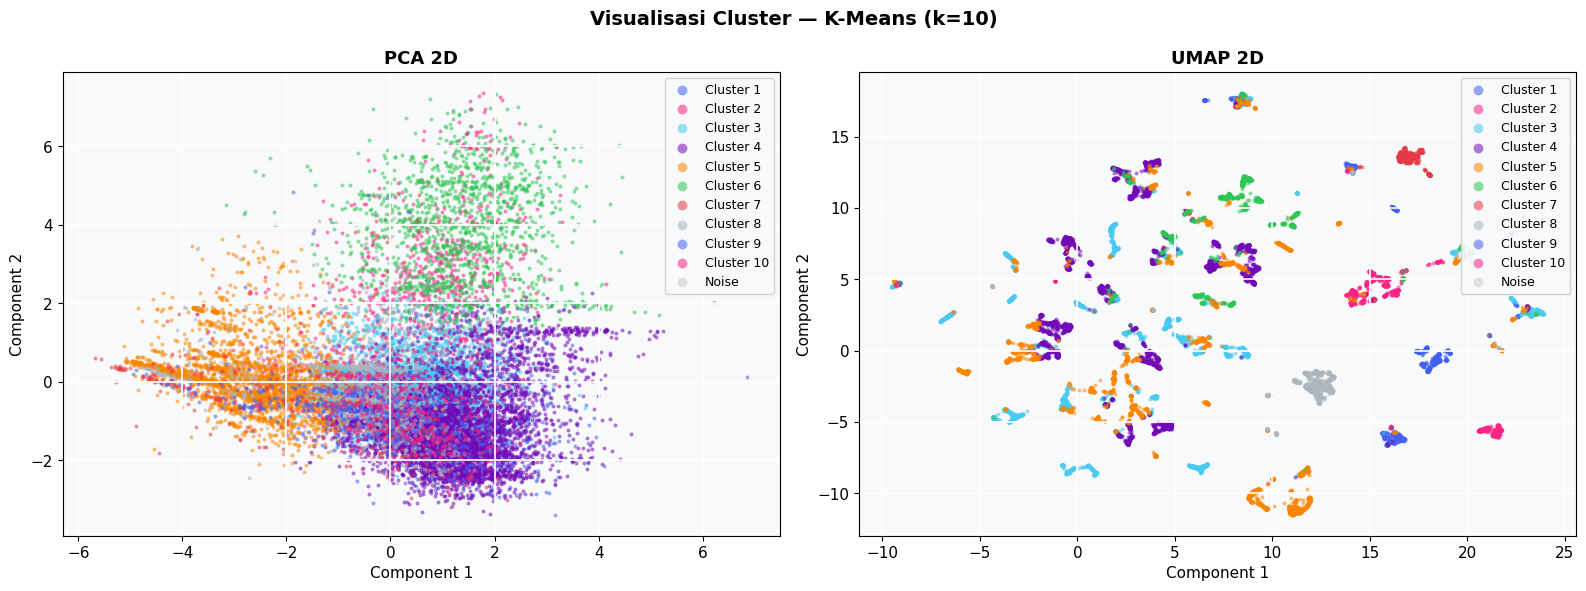

In [ ]:
# Figure 2: Scatter PCA + UMAP (best algo) 
mask_valid = best_labels >= 0
n_clusters_best = results[best_algo]['n_clusters']
cluster_palette = {f'Cluster {i+1}': PALETTE[i % len(PALETTE)]
                   for i in range(n_clusters_best)}
cluster_palette['Noise'] = '#cccccc'

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle(f'Visualisasi Cluster — {best_algo} (k={results[best_algo]["n_clusters"]})',
              fontsize=14, fontweight='bold')

for ax, X_2d, title in zip(axes2,
                            [X_pca_2d, X_umap],
                            ['PCA 2D', 'UMAP 2D']):
    for label_str, color in cluster_palette.items():
        mask = df['cluster_str'] == label_str
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=label_str, alpha=0.55,
                   s=8, linewidths=0)
    ax.set_title(title)
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(markerscale=2.5, fontsize=9,
              loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

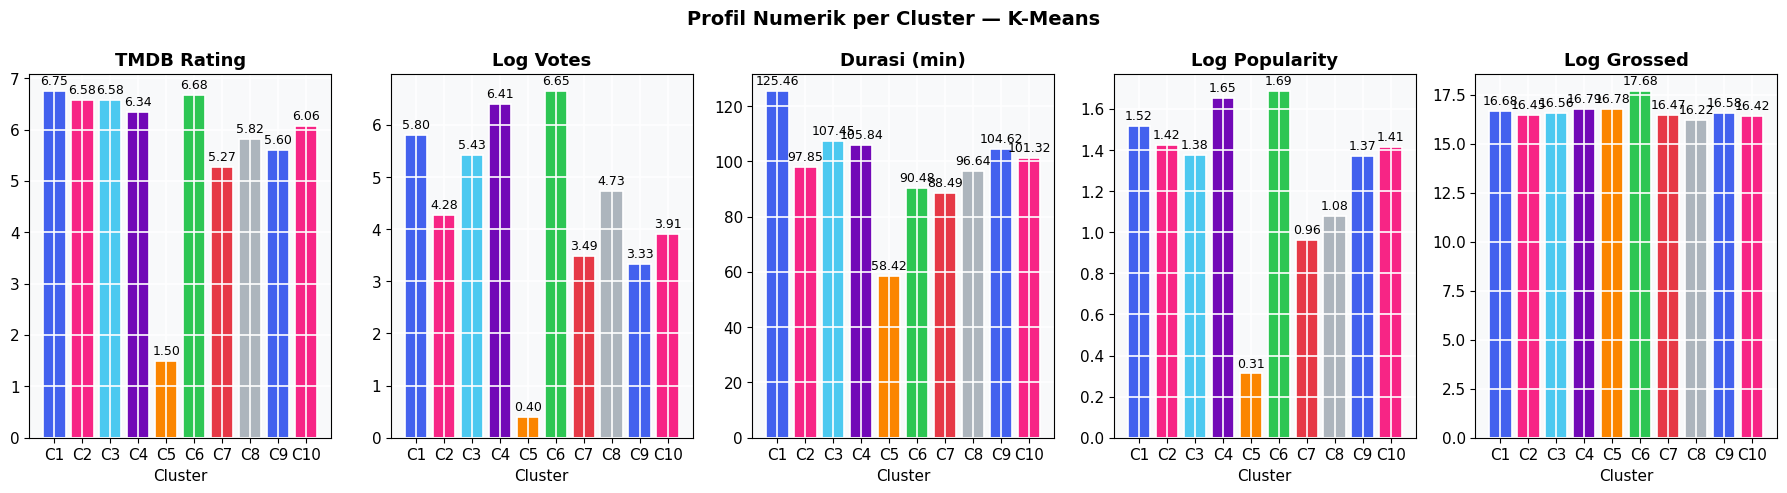

In [ ]:
# Figure 3: Profil cluster — radar / bar numerik 
# Hanya pakai cluster valid (non-noise)
df_clean = df[df['cluster'] >= 0].copy()
profile_cols = ['TMDB Rating', 'log_votes', 'Duration',
                'log_popularity', 'log_grossed']
profile_labels = ['TMDB Rating', 'Log Votes', 'Durasi (min)',
                  'Log Popularity', 'Log Grossed']

cluster_profile = df_clean.groupby('cluster')[profile_cols].mean()

fig3, axes3 = plt.subplots(1, len(profile_cols), figsize=(18, 5), sharey=False)
fig3.suptitle(f'Profil Numerik per Cluster — {best_algo}',
              fontsize=14, fontweight='bold')

for ax, col, label in zip(axes3, profile_cols, profile_labels):
    vals   = cluster_profile[col].values
    labels = [f'C{i+1}' for i in cluster_profile.index]
    bars = ax.bar(labels, vals,
                  color=[PALETTE[i % len(PALETTE)] for i in cluster_profile.index],
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(vals),
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

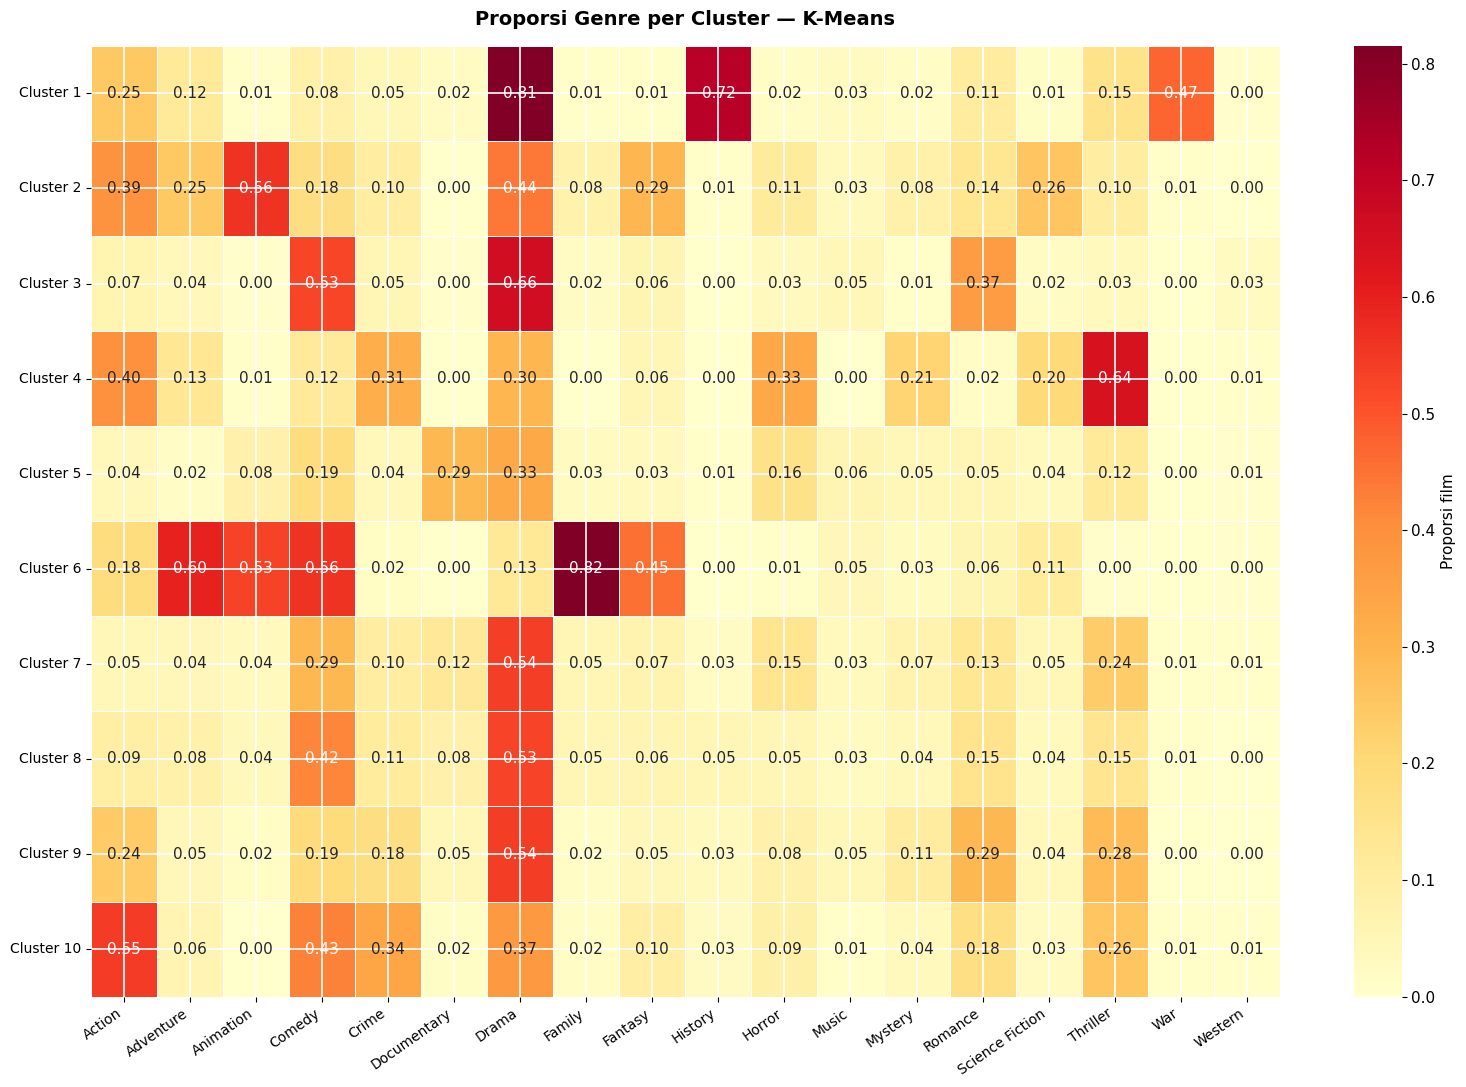

In [ ]:
# Figure 4: Genre heatmap per cluster
genre_heat = df_clean.groupby('cluster')[genre_cols].mean()
genre_heat.index = [f'Cluster {i+1}' for i in genre_heat.index]
genre_heat.columns = [c.replace('genre_','').replace('_',' ') for c in genre_cols]

fig4, ax4 = plt.subplots(figsize=(16, max(4, n_clusters_best * 0.9 + 2)))
sns.heatmap(genre_heat, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax4,
            cbar_kws={'label': 'Proporsi film'})
ax4.set_title(f'Proporsi Genre per Cluster — {best_algo}',
              fontsize=14, fontweight='bold', pad=15)
ax4.set_ylabel('')
ax4.set_xlabel('')
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

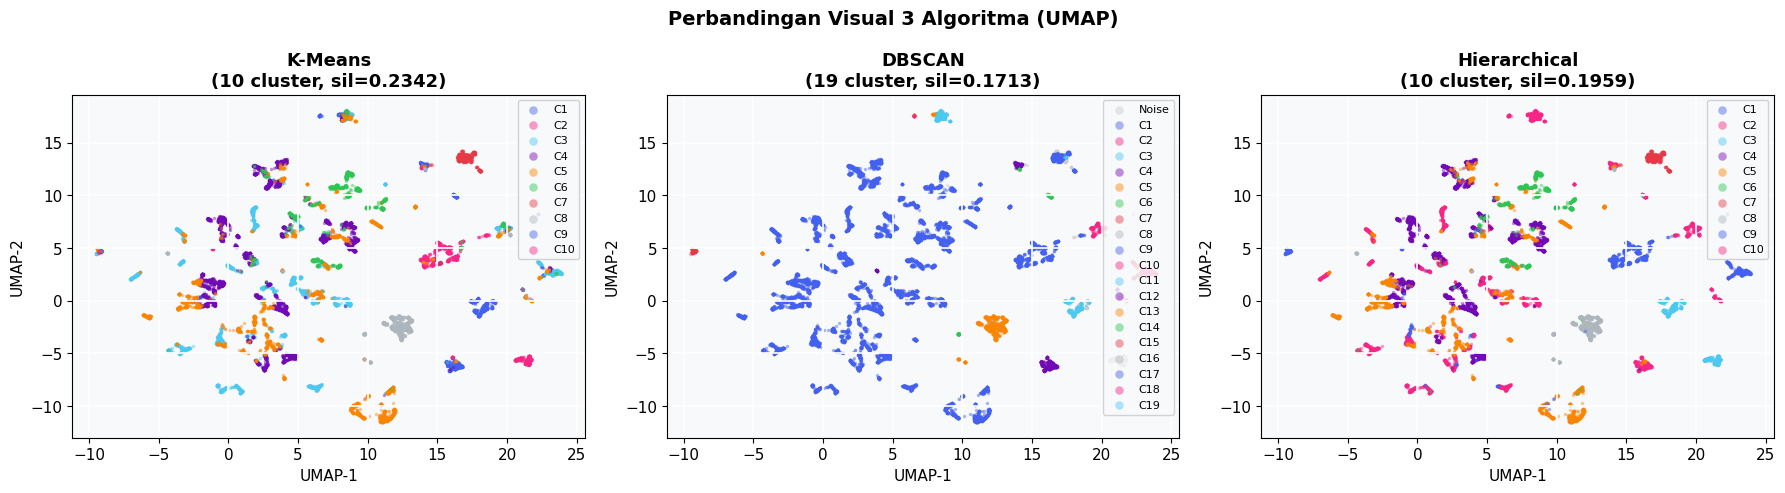

In [ ]:
# Figure 5: Scatter UMAP 3 algoritma side-by-side
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 5))
fig5.suptitle('Perbandingan Visual 3 Algoritma (UMAP)', fontsize=14, fontweight='bold')

algo_label_map = {
    'K-Means': km_labels,
    'DBSCAN':  db_labels_raw,
    'Hierarchical': hc_labels,
}
for ax, (aname, alabs) in zip(axes5, algo_label_map.items()):
    unique_l = sorted(set(alabs))
    for i, ul in enumerate(unique_l):
        mask = alabs == ul
        lbl = 'Noise' if ul == -1 else f'C{ul+1}'
        col = '#cccccc' if ul == -1 else PALETTE[ul % len(PALETTE)]
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=col, label=lbl, alpha=0.45, s=6, linewidths=0)
    sil_str = f"sil={results[aname]['silhouette']:.4f}" if results[aname]['silhouette'] else 'N/A'
    ax.set_title(f'{aname}\n({results[aname]["n_clusters"]} cluster, {sil_str})')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(markerscale=2.5, fontsize=8, loc='upper right', framealpha=0.85)

plt.tight_layout()
plt.show()

In [ ]:
# Cetak ringkasan profil tiap cluster 
print("\n" + "=" * 60)
print("  RINGKASAN PROFIL CLUSTER")
print("=" * 60)
for cid in sorted(df_clean['cluster'].unique()):
    sub = df_clean[df_clean['cluster'] == cid]
    top_genre = sub[genre_cols].mean().idxmax().replace('genre_','').replace('_',' ')
    top_lang  = sub['Original Language'].value_counts().idxmax()
    print(f"\n  ▶ Cluster {cid+1} ({len(sub):,} film)")
    print(f"    Rating   : {sub['TMDB Rating'].mean():.2f}")
    print(f"    Votes    : {sub['Votes'].median():,.0f} (median)")
    print(f"    Durasi   : {sub['Duration'].mean():.0f} menit")
    print(f"    Grossed  : ${sub['Grossed in $'].median():,.0f} (median)")
    print(f"    Genre dom: {top_genre}")
    print(f"    Bahasa   : {top_lang}")
    print(f"    Sample   : {sub['Movie Name'].sample(min(3, len(sub))).tolist()}")


  RINGKASAN PROFIL CLUSTER

  ▶ Cluster 1 (936 film)
    Rating   : 6.75
    Votes    : 514 (median)
    Durasi   : 125 menit
    Grossed  : $21,760,713 (median)
    Genre dom: Drama
    Bahasa   : en
    Sample   : ['Warfare', 'Warhorse One', "Kelly's Heroes"]

  ▶ Cluster 2 (1,057 film)
    Rating   : 6.58
    Votes    : 94 (median)
    Durasi   : 98 menit
    Grossed  : $21,760,713 (median)
    Genre dom: Animation
    Bahasa   : ja
    Sample   : ['Moonlight Mask: Claws of Satan', 'Lucky Sky Diamond', 'One Piece: Adventure of Nebulandia']

  ▶ Cluster 3 (4,834 film)
    Rating   : 6.58
    Votes    : 424 (median)
    Durasi   : 107 menit
    Grossed  : $21,760,713 (median)
    Genre dom: Drama
    Bahasa   : en
    Sample   : ['Sunrise: A Song of Two Humans', 'The Story of Us', "Don't Look Up"]

  ▶ Cluster 4 (4,490 film)
    Rating   : 6.34
    Votes    : 788 (median)
    Durasi   : 106 menit
    Grossed  : $21,760,713 (median)
    Genre dom: Thriller
    Bahasa   : en
    Sample